<a href="https://colab.research.google.com/github/hannahandkush/Coursework/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise 8

Number of sites in Douro and Tejo basins: 888
Environmental variables used for clustering: ['log1p_Altitude', 'log1p_Actual_river_slope', 'sqrt_Elevation_mean_catch', 'prec_ann_catch', 'temp_ann']


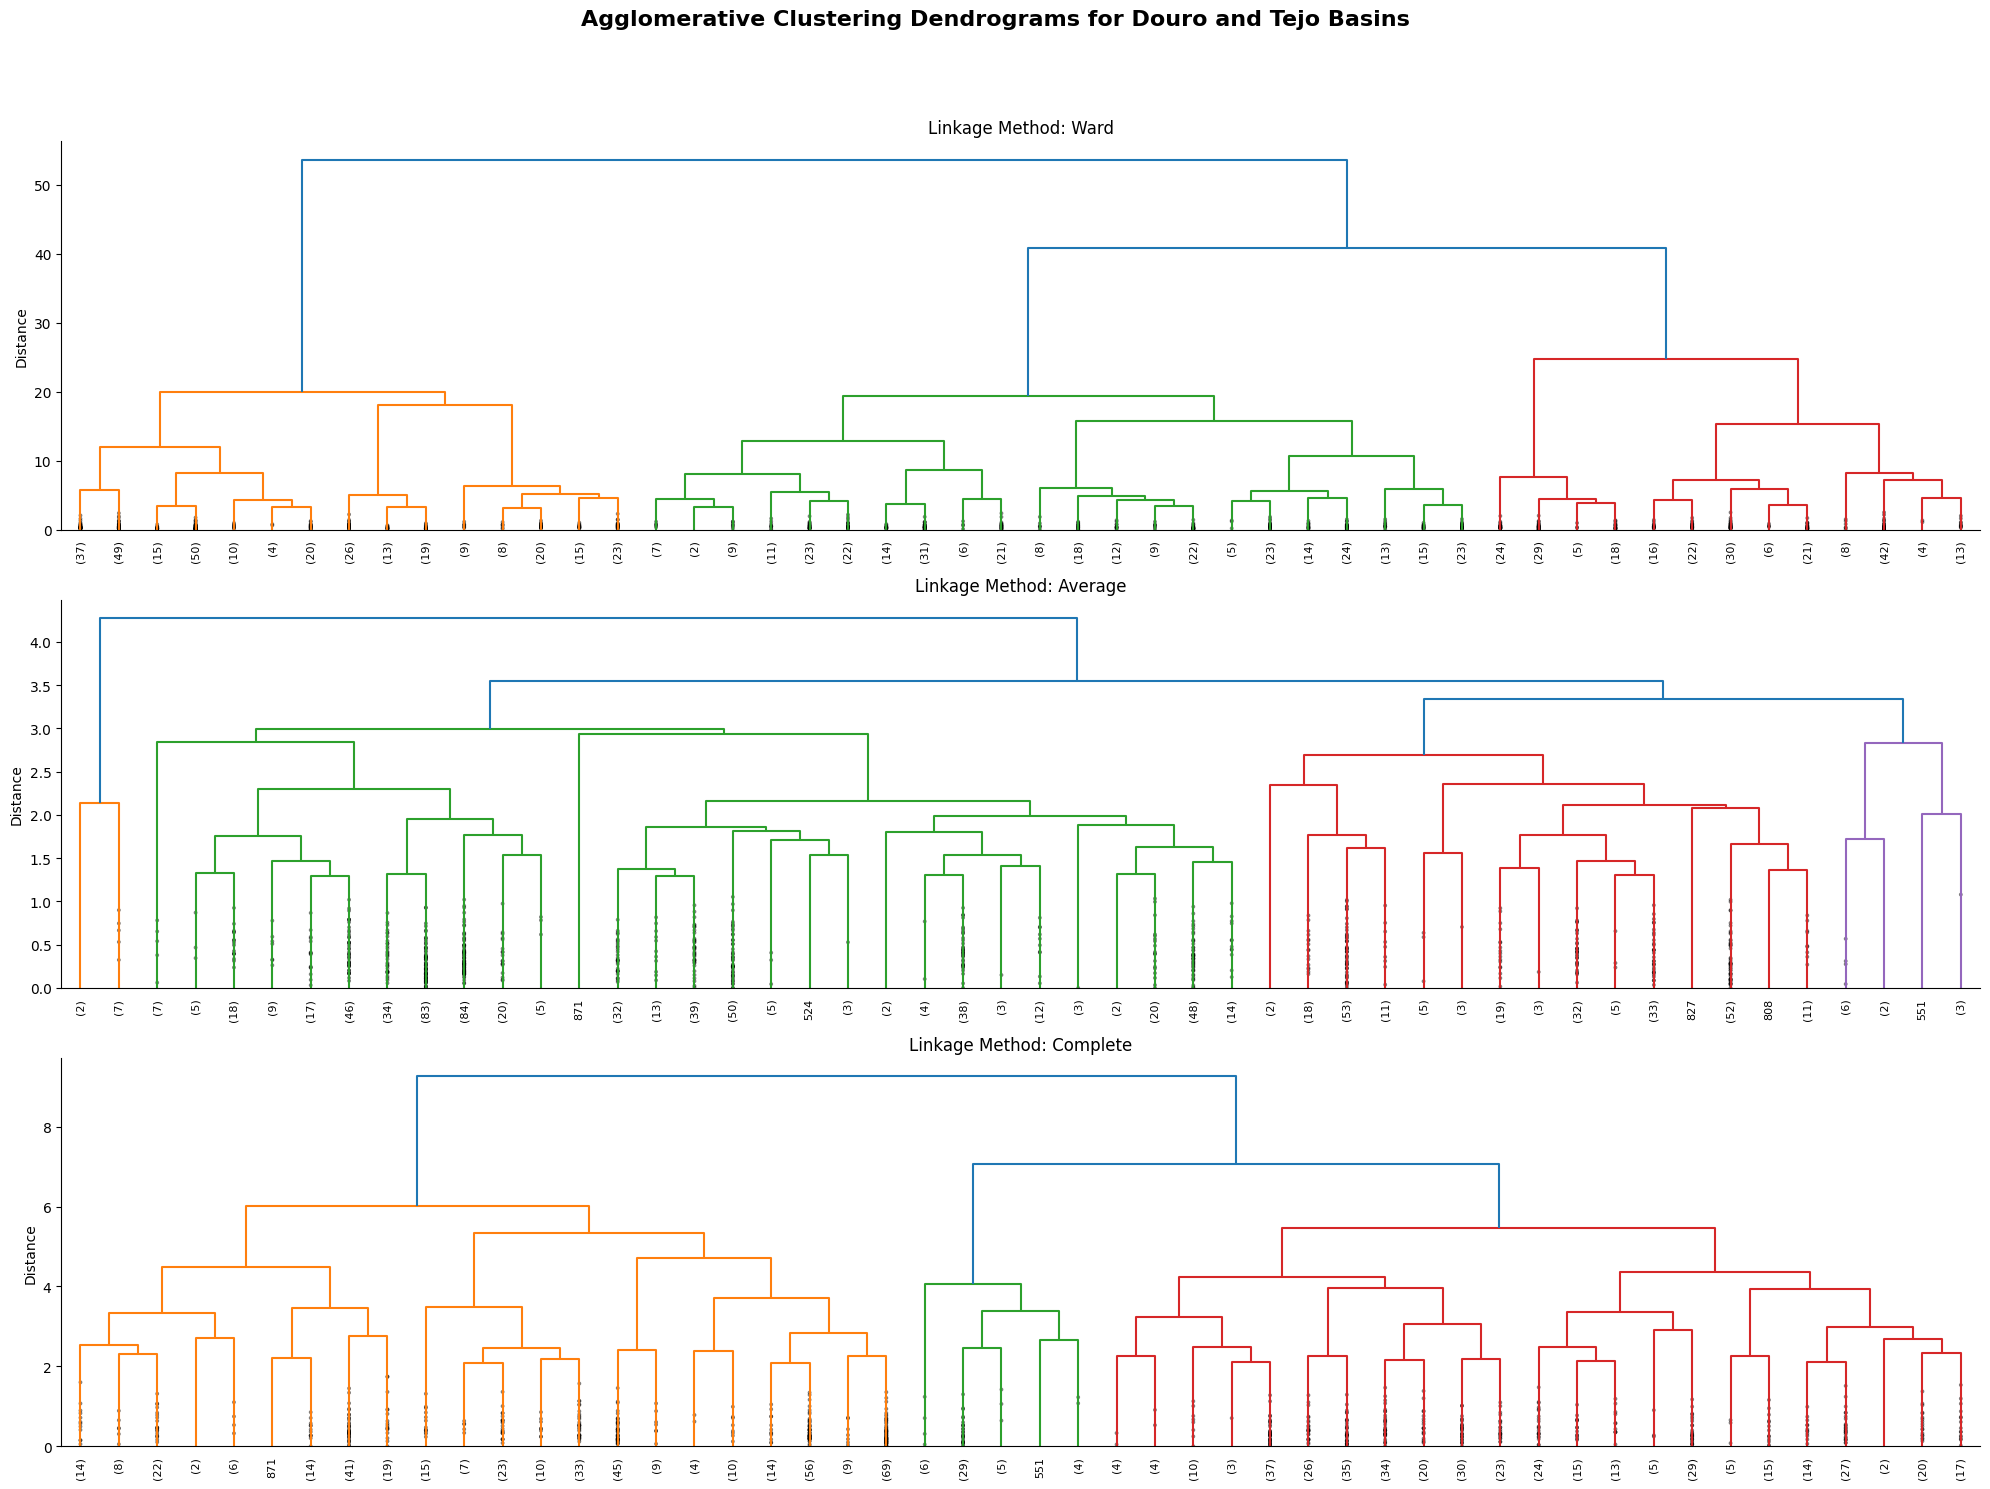

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Load data (copied from cell ANtMSbrFfhdv)
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

# Apply transformations (copied from cell GcArzq8sfhdy)
df['log1p_Altitude'] = np.log1p(df['Altitude'])
df['log1p_Actual_river_slope'] = np.log1p(df['Actual_river_slope'])
df['sqrt_Elevation_mean_catch'] = np.sqrt(df['Elevation_mean_catch'])

# 1. Filter data for Douro and Tejo basins
douro_tejo_df = df[df['Catchment_name'].isin(['Douro', 'Tejo'])].copy()

# Select the quantitative environmental variables used in the parsimonious model
# These are already transformed and address multicollinearity
env_vars_for_clustering = [
    'log1p_Altitude',
    'log1p_Actual_river_slope',
    'sqrt_Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann'
]

X_clustering = douro_tejo_df[env_vars_for_clustering].dropna()

# Keep track of the original site codes for labeling dendrograms (optional but good practice)
site_codes = X_clustering.index

print(f"Number of sites in Douro and Tejo basins: {X_clustering.shape[0]}")
print(f"Environmental variables used for clustering: {env_vars_for_clustering}")

# 2. Standardize the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 3. Perform agglomerative clustering using different linkage methods
linkage_methods = ['ward', 'average', 'complete']

plt.figure(figsize=(20, 15))
plt.suptitle('Agglomerative Clustering Dendrograms for Douro and Tejo Basins',
             fontsize=16, fontweight='bold', y=1.02)

for i, method in enumerate(linkage_methods):
    plt.subplot(3, 1, i + 1)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z,
               truncate_mode='lastp',  # Show only the last p merged clusters
               p=50,                  # Show top 50 clusters
               show_leaf_counts=True,
               leaf_rotation=90.,
               leaf_font_size=8.,
               show_contracted=True)
    plt.title(f'Linkage Method: {method.capitalize()}')
    plt.ylabel('Distance')
    for spine in ['top', 'right']: # hide spines
        plt.gca().spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

<Figure size 1200x1000 with 0 Axes>

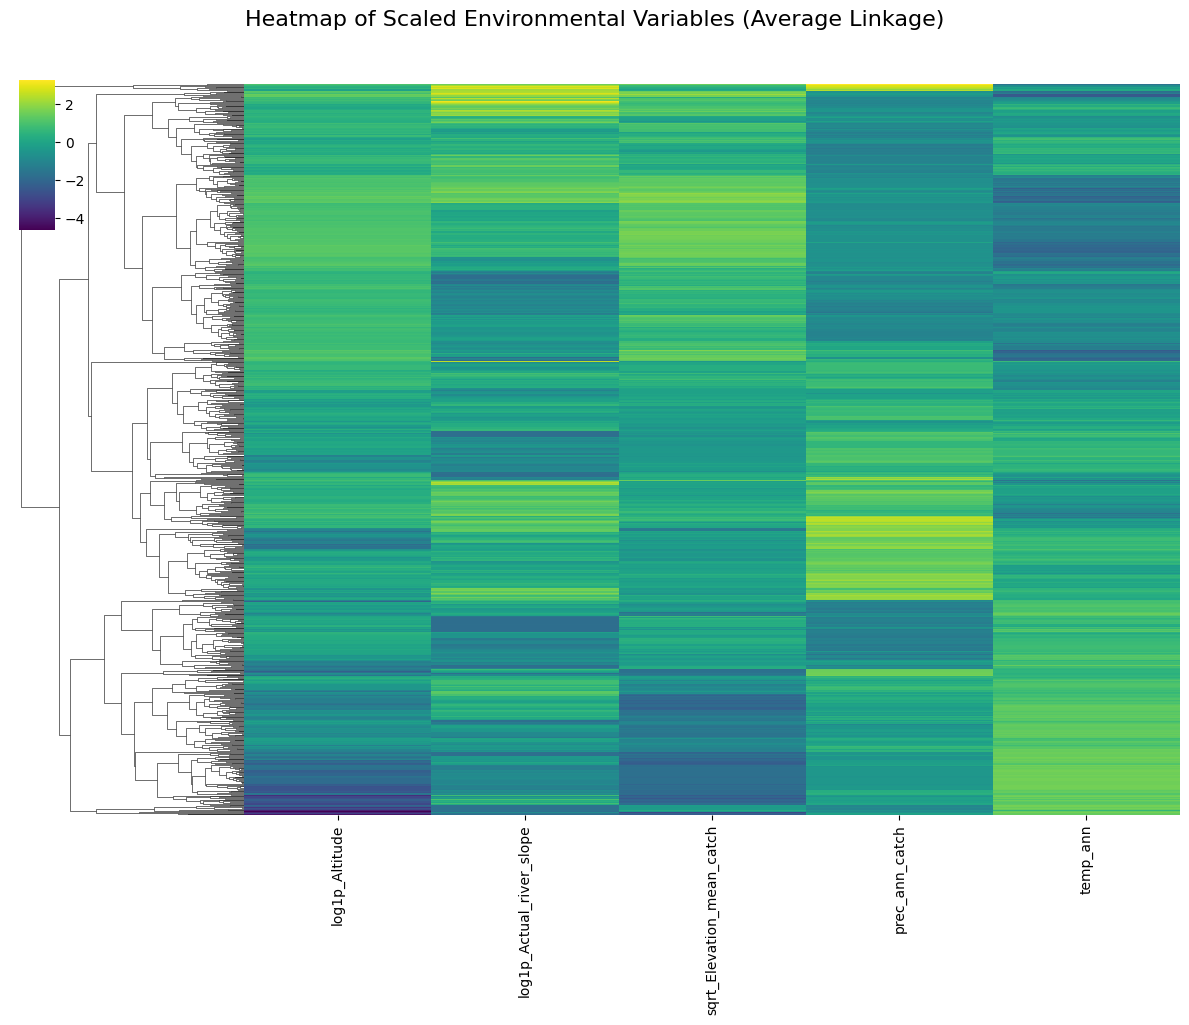

In [ ]:
import seaborn as sns

# Create a DataFrame from the scaled data for better labeling
X_scaled_df = pd.DataFrame(X_scaled, columns=env_vars_for_clustering, index=X_clustering.index)

# Plot the clustermap with average linkage
# row_linkage and col_linkage can be set to the Z matrix from scipy.cluster.hierarchy.linkage
# However, clustermap can also compute it internally if given the 'method' parameter.
# For reproducibility and consistency, we can pass the pre-computed Z matrix for average linkage
Z_average = linkage(X_scaled, method='average')

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

sns.clustermap(X_scaled_df,
               method='average',
               metric='euclidean', # Default metric for linkage
               cmap='viridis', # Colormap for the heatmap
               figsize=(12, 10),
               row_cluster=True, # Cluster rows
               col_cluster=False, # Do not cluster columns (variables are already selected/ordered)
               dendrogram_ratio=(.2, .05), # Ratios for row and column dendrograms
               cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the colorbar
               yticklabels=False) # Hide y-axis labels (site codes) for clarity if too many

plt.suptitle('Heatmap of Scaled Environmental Variables (Average Linkage)', y=1.02, fontsize=16)
plt.show()

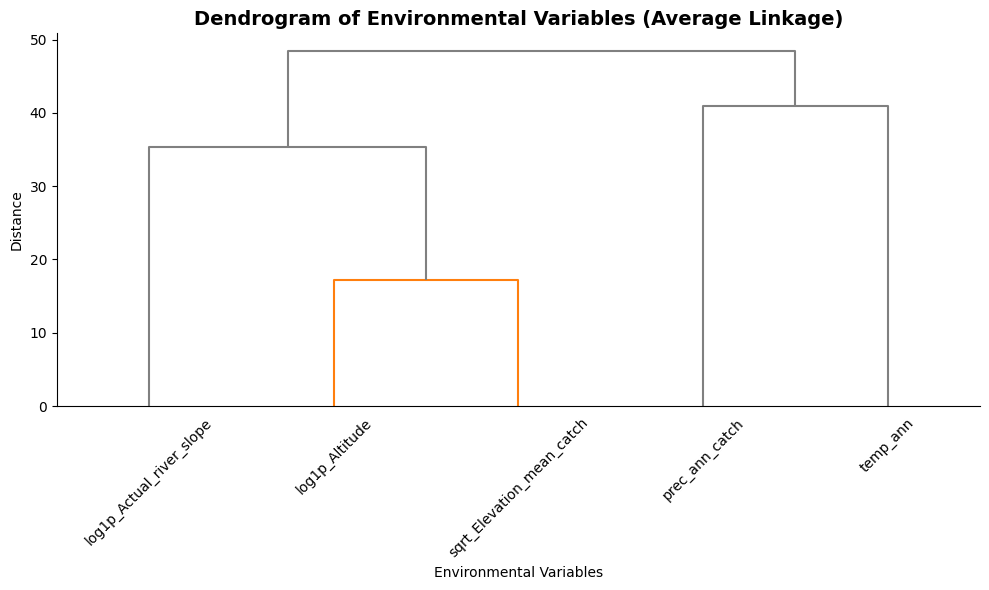

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Transpose the scaled data to cluster variables (columns)
X_scaled_T = X_scaled.T

# Perform hierarchical clustering on the transposed data using 'average' linkage
Z_vars_average = linkage(X_scaled_T, method='average', metric='euclidean')

plt.figure(figsize=(10, 6))
plt.title('Dendrogram of Environmental Variables (Average Linkage)',
          fontsize=14, fontweight='bold')
plt.xlabel('Environmental Variables')
plt.ylabel('Distance')
dendrogram(Z_vars_average,
           labels=env_vars_for_clustering, # Use the original variable names as labels
           leaf_rotation=45.,
           leaf_font_size=10.,
           color_threshold=0.7 * max(Z_vars_average[:,2]), # Optional: color clusters below a certain threshold
           above_threshold_color='gray')
for spine in ['top', 'right']: # hide spines
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Multicollinearity among predictor variables can destabilise regression coefficients and inflate standard errors, making it difficult to interpret which variables are genuinely driving the response. Average linkage clustering produces a dendrogram that groups variables by their correlation structure, providing a visual basis for variable selection prior to modelling. Variables joining at low distances, such as log1p_Altitude and sqrt_Elevation_mean_catch here, are strongly correlated and should not both be retained. One variable from each cluster should be selected based on ecological relevance or individual predictive performance, with VIF diagnostics used to confirm the final set.

**Prompts**

Prompt 1

Using the dataframe df loaded from EFIplus_medit.zip, filter sites from the Douro and Tejo basins, scale the quantitative environmental variables, and run agglomerative cluster analysis using ward, average, and complete linkage methods. Include all data loading steps in the same cell and plot a dendrogram for each linkage method.

Prompt 2

Using the scaled environmental variables for Douro and Tejo sites in df, plot a clustered heatmap and a separate dendrogram that groups the environmental variables (columns, not rows) by their similarity. Use average linkage for both, and transpose the data where necessary to cluster columns rather than sites.